In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [3]:
# Load the cleaned datasets (Replace with your actual file paths)
bnd_data = pd.read_csv("../data/BND_cleaned.csv", index_col="Date", parse_dates=True)
spy_data = pd.read_csv("../data/SPY_cleaned.csv", index_col="Date", parse_dates=True)

# Ensure data is sorted by date
bnd_data = bnd_data.sort_index()
spy_data = spy_data.sort_index()

# Display the first few rows
print(bnd_data.head(), "\n")
print(spy_data.head())


                Close       High        Low       Open   Volume
Date                                                           
2015-01-02  62.573112  62.603397  62.398980  62.406553  2218800
2015-01-05  62.754818  62.777530  62.610970  62.641254  5820100
2015-01-06  62.936508  63.125780  62.860801  62.860801  3887600
2015-01-07  62.974358  63.050065  62.875939  62.944073  2433400
2015-01-08  62.875977  62.921400  62.815408  62.921400  1873400 

                 Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  172.592865  173.811099  171.542672  173.391022  121465900
2015-01-05  169.475922  171.702325  169.165069  171.534297  169632600
2015-01-06  167.879578  170.316019  167.073024  169.786718  209151400
2015-01-07  169.971619  170.316085  168.770204  169.223882  125346700
2015-01-08  172.987732  173.206180  171.383047  171.399841  147217800


In [4]:
# Define SARIMA order (same as TSLA)
sarima_order = (2, 1, 4)
seasonal_order = (0, 1, 1, 12)

# Train SARIMA model for BND
bnd_model = SARIMAX(bnd_data["Close"], order=sarima_order, seasonal_order=seasonal_order)
bnd_result = bnd_model.fit(disp=False)

# Print model summary
print(bnd_result.summary())


c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                                Close   No. Observations:                 2535
Model:             SARIMAX(2, 1, 4)x(0, 1, [1], 12)   Log Likelihood                   5.468
Date:                              Mon, 03 Mar 2025   AIC                              5.063
Time:                                      06:09:41   BIC                             51.726
Sample:                                           0   HQIC                            21.996
                                             - 2535                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4326      0.055      7.820      0.000       0.324       0.541
ar.L2         -0.81

In [5]:
# Train SARIMA model for SPY
spy_model = SARIMAX(spy_data["Close"], order=sarima_order, seasonal_order=seasonal_order)
spy_result = spy_model.fit(disp=False)

# Print model summary
print(spy_result.summary())


c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found

                                      SARIMAX Results                                       
Dep. Variable:                                Close   No. Observations:                 2535
Model:             SARIMAX(2, 1, 4)x(0, 1, [1], 12)   Log Likelihood               -6753.825
Date:                              Mon, 03 Mar 2025   AIC                          13523.649
Time:                                      06:10:46   BIC                          13570.312
Sample:                                           0   HQIC                         13540.583
                                             - 2535                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.6420      0.066    -24.915      0.000      -1.771      -1.513
ar.L2         -0.76

In [6]:
# Define forecast horizon (126 business days for ~6 months)
forecast_steps = 126  

# Generate forecast
bnd_forecast = bnd_result.get_forecast(steps=forecast_steps)
bnd_predicted_mean = bnd_forecast.predicted_mean
bnd_conf_int = bnd_forecast.conf_int()

# Create forecast DataFrame for BND
bnd_forecast_df = pd.DataFrame({
    "BND Forecast": bnd_predicted_mean.values,
    "BND Lower Bound": bnd_conf_int.iloc[:, 0].values,
    "BND Upper Bound": bnd_conf_int.iloc[:, 1].values
}, index=pd.date_range(start=bnd_data.index[-1], periods=forecast_steps+1, freq="B")[1:])

print(bnd_forecast_df.head())


            BND Forecast  BND Lower Bound  BND Upper Bound
2025-01-31     72.231672        71.763320        72.700024
2025-02-03     72.252497        71.591886        72.913108
2025-02-04     72.262324        71.476355        73.048293
2025-02-05     72.249227        71.362806        73.135648
2025-02-06     72.245468        71.260341        73.230596


c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [7]:
# Generate forecast for SPY
spy_forecast = spy_result.get_forecast(steps=forecast_steps)
spy_predicted_mean = spy_forecast.predicted_mean
spy_conf_int = spy_forecast.conf_int()

# Create forecast DataFrame for SPY
spy_forecast_df = pd.DataFrame({
    "SPY Forecast": spy_predicted_mean.values,
    "SPY Lower Bound": spy_conf_int.iloc[:, 0].values,
    "SPY Upper Bound": spy_conf_int.iloc[:, 1].values
}, index=pd.date_range(start=spy_data.index[-1], periods=forecast_steps+1, freq="B")[1:])

print(spy_forecast_df.head())


            SPY Forecast  SPY Lower Bound  SPY Upper Bound
2025-01-31    605.651258       598.747988       612.554528
2025-02-03    605.274650       595.779860       614.769441
2025-02-04    606.055563       594.510245       617.600882
2025-02-05    605.825695       592.545333       619.106058
2025-02-06    606.868277       592.143857       621.592696


c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [15]:
# Assuming 'forecast_df' contains the TSLA forecast from Task 3
portfolio_forecast = pd.concat([forecast_df, bnd_forecast_df, spy_forecast_df], axis=1)

# Display the first few rows
print(portfolio_forecast.head())


              Forecast  Lower Bound  Upper Bound  BND Forecast  \
2025-01-31  143.014965   132.317940   153.711990     72.231672   
2025-02-03  141.989397   127.015024   156.963769     72.252497   
2025-02-04  143.432374   125.028765   161.835983     72.262324   
2025-02-05  143.604400   122.394655   164.814145     72.249227   
2025-02-06  142.517949   118.489137   166.546761     72.245468   

            BND Lower Bound  BND Upper Bound  SPY Forecast  SPY Lower Bound  \
2025-01-31        71.763320        72.700024    605.651258       598.747988   
2025-02-03        71.591886        72.913108    605.274650       595.779860   
2025-02-04        71.476355        73.048293    606.055563       594.510245   
2025-02-05        71.362806        73.135648    605.825695       592.545333   
2025-02-06        71.260341        73.230596    606.868277       592.143857   

            SPY Upper Bound  
2025-01-31       612.554528  
2025-02-03       614.769441  
2025-02-04       617.600882  
2025-02-

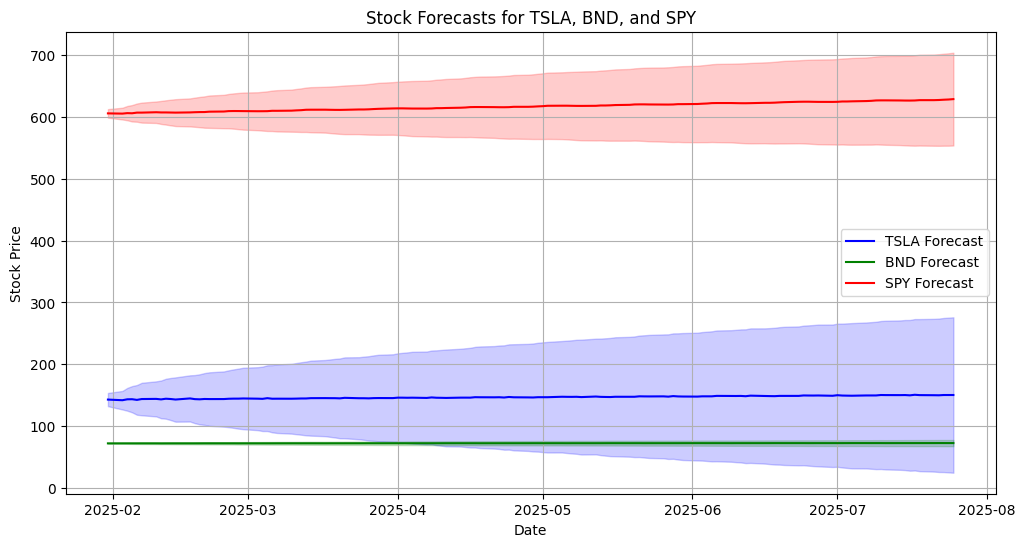

In [16]:
plt.figure(figsize=(12, 6))

# Plot TSLA forecast
plt.plot(portfolio_forecast.index, portfolio_forecast["Forecast"], label="TSLA Forecast", color="blue")
plt.fill_between(portfolio_forecast.index, portfolio_forecast["Lower Bound"], portfolio_forecast["Upper Bound"], color="blue", alpha=0.2)

# Plot BND forecast
plt.plot(portfolio_forecast.index, portfolio_forecast["BND Forecast"], label="BND Forecast", color="green")
plt.fill_between(portfolio_forecast.index, portfolio_forecast["BND Lower Bound"], portfolio_forecast["BND Upper Bound"], color="green", alpha=0.2)

# Plot SPY forecast
plt.plot(portfolio_forecast.index, portfolio_forecast["SPY Forecast"], label="SPY Forecast", color="red")
plt.fill_between(portfolio_forecast.index, portfolio_forecast["SPY Lower Bound"], portfolio_forecast["SPY Upper Bound"], color="red", alpha=0.2)

plt.legend()
plt.title("Stock Forecasts for TSLA, BND, and SPY")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.grid()
plt.show()


In [17]:
import numpy as np
import pandas as pd

# Sample forecasted prices (replace these with your actual forecast results)
forecasted_prices = pd.DataFrame({
    'BND': [72.231672, 72.252497, 72.262324, 72.249227, 72.245468],
    'SPY': [605.651258, 605.274650, 606.055563, 605.825695, 606.868277]
}, index=pd.to_datetime(['2025-01-31', '2025-02-03', '2025-02-04', '2025-02-05', '2025-02-06']))

# Compute daily returns
returns = forecasted_prices.pct_change().dropna()
print(returns)


                 BND       SPY
2025-02-03  0.000288 -0.000622
2025-02-04  0.000136  0.001290
2025-02-05 -0.000181 -0.000379
2025-02-06 -0.000052  0.001721


In [18]:
# Compute the covariance matrix
cov_matrix = returns.cov()
print(cov_matrix)


              BND           SPY
BND  4.268376e-08 -4.019862e-08
SPY -4.019862e-08  1.382217e-06


In [21]:
num_portfolios = 10000
np.random.seed(42)

# Generate random portfolio weights
weights = np.random.dirichlet(np.ones(2), num_portfolios)

# Compute portfolio returns and risks
portfolio_returns = np.dot(weights, returns.mean())
portfolio_risks = np.sqrt(np.einsum('ij,jk,ik->i', weights, cov_matrix, weights))

# Store results
portfolio_df = pd.DataFrame({
    'Return': portfolio_returns,
    'Risk': portfolio_risks,
    'BND Weight': weights[:, 0],
    'SPY Weight': weights[:, 1]
})

print(portfolio_df.head())


     Return      Risk  BND Weight  SPY Weight
0  0.000441  0.001013    0.134871    0.865129
1  0.000234  0.000477    0.590551    0.409449
2  0.000275  0.000580    0.500042    0.499958
3  0.000489  0.001141    0.028893    0.971107
4  0.000308  0.000664    0.427414    0.572586


In [22]:
sharpe_ratios = portfolio_returns / portfolio_risks
max_sharpe_idx = np.argmax(sharpe_ratios)

optimal_portfolio = portfolio_df.iloc[max_sharpe_idx]
print("Optimal Portfolio:")
print(optimal_portfolio)


Optimal Portfolio:
Return        0.000145
Risk          0.000275
BND Weight    0.786892
SPY Weight    0.213108
Name: 7915, dtype: float64


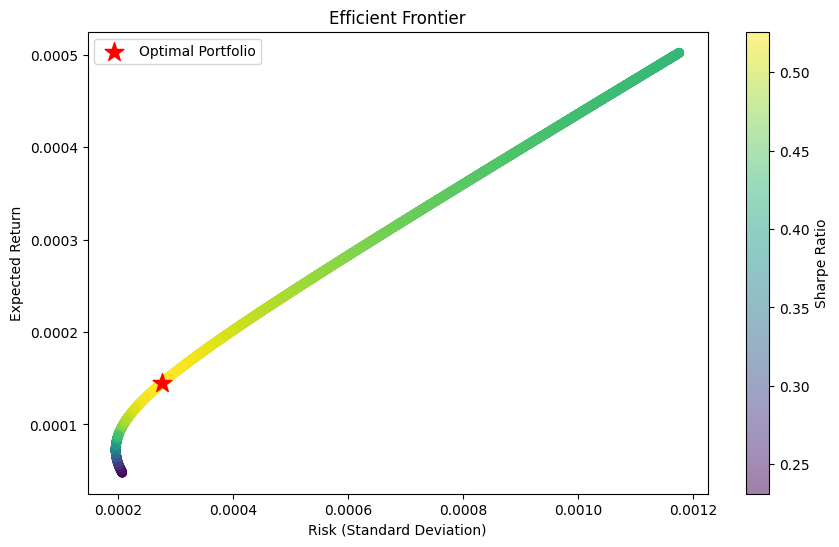

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(portfolio_df['Risk'], portfolio_df['Return'], c=sharpe_ratios, cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.scatter(optimal_portfolio['Risk'], optimal_portfolio['Return'], color='red', marker='*', s=200, label='Optimal Portfolio')
plt.legend()
plt.show()


In [24]:
annual_return = optimal_portfolio['Return'] * 252
annual_risk = optimal_portfolio['Risk'] * np.sqrt(252)

print(f"Annualized Return: {annual_return:.4%}")
print(f"Annualized Risk: {annual_risk:.4%}")


Annualized Return: 3.6457%
Annualized Risk: 0.4368%


In [25]:
risk_free_rate = 0.02  # 2% annualized
sharpe_ratio = (annual_return - risk_free_rate) / annual_risk
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")


Sharpe Ratio: 3.77
